In [153]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.10.0+cu128'

In [154]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

weight = 0.7
bias = 0.3

# Create synthetic linear data on CPU for easier plotting/debugging
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)  # shape: (N, 1)
y = weight * X + bias

X[:7], X.shape

Using device: cuda


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200]]),
 torch.Size([50, 1]))

In [155]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

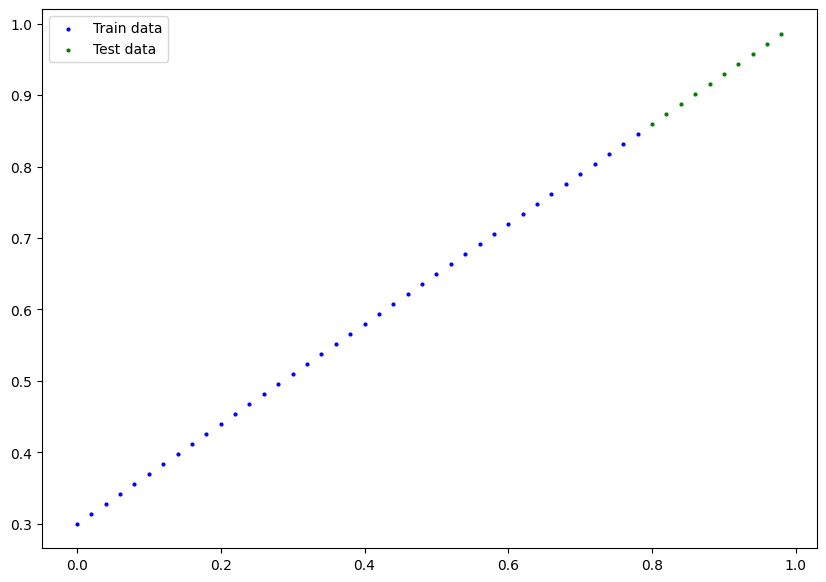

In [156]:
#visualize the data
def plot_predictions(train_data=X_train.cpu(), train_labels=y_train.cpu(), test_data=X_test.cpu(), test_labels=y_test.cpu(), predictions=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Train data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend()

plot_predictions()

In [157]:
# build a linear regression model by hand

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias

In [158]:
model_0 = LinearRegressionModel()
print(list(model_0.parameters()))

print(model_0.state_dict())
print(next(model_0.parameters()).device)

[Parameter containing:
tensor([0.5139], requires_grad=True), Parameter containing:
tensor([1.2968], requires_grad=True)]
OrderedDict([('weight', tensor([0.5139])), ('bias', tensor([1.2968]))])
cpu


In [159]:
print(X_test[:5], y_test[:5])

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800]]) tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160]])


tensor([[1.7079],
        [1.7182],
        [1.7284],
        [1.7387],
        [1.7490]], device='cuda:0')


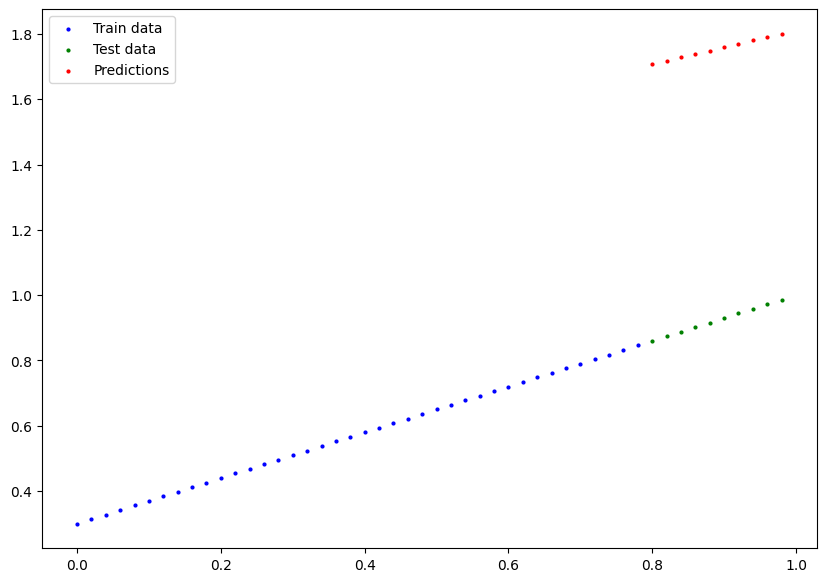

In [160]:
# Move model and tensor copies to the selected device once
model_0.to(device)
X_train_device = X_train.to(device)
y_train_device = y_train.to(device)
X_test_device = X_test.to(device)

with torch.inference_mode(): #instead of torch.no_grad() we can use torch.inference_mode() which is a more efficient way to disable gradient tracking
    y_preds = model_0(X_test_device)

plot_predictions(predictions=y_preds.cpu())
print(y_preds[:5])

In [161]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

epochs = 385 # loop through the data

for epoch in range(epochs):
    model_0.train() # set the model to training mode. sets all parameters to require gradients

    y_pred = model_0(X_train_device) # forward pass

    loss = loss_fn(y_pred, y_train_device) # calculate the loss

    optimizer.zero_grad() # zero the gradients

    loss.backward() # backpropagation

    optimizer.step() # update the parameters

    model_0.eval() # set the model to evaluation mode. disables gradient tracking



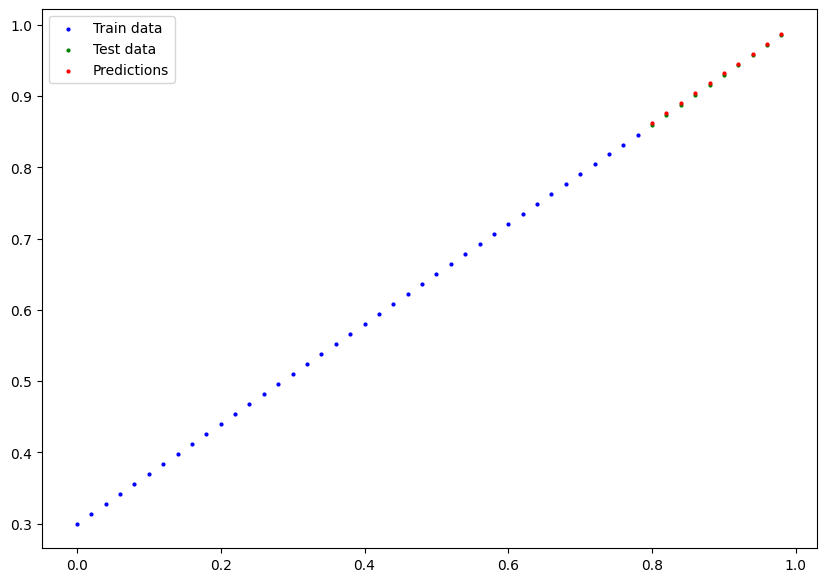

In [162]:
with torch.inference_mode():
    y_preds_new = model_0(X_test_device)

plot_predictions(predictions=y_preds_new.cpu())

In [163]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"saving model to: {MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)


saving model to: models\01_pytorch_workflow_model_0.pth


cuda:0


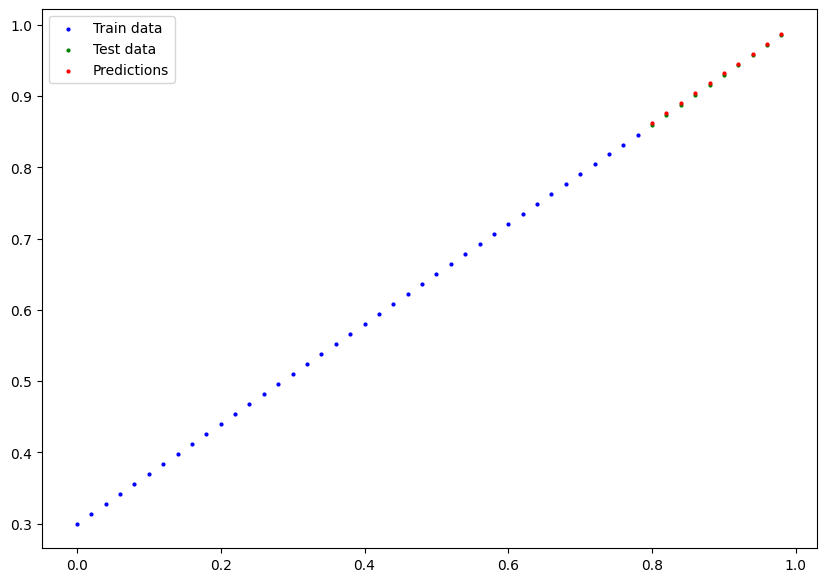

In [164]:
# load the model safely on whichever device is currently available
model_0_loaded = LinearRegressionModel().to(device)
model_0_loaded.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model_0_loaded.eval()

with torch.inference_mode():
    loaded_y_preds = model_0_loaded(X_test_device)

plot_predictions(predictions=loaded_y_preds.cpu())
print(loaded_y_preds.device)